<B><h1 style="color: Red; font-size: 36px; text-align: center; font-family: Arial, sans-serif;">
  Accident Analysis using LogisticRegression
</h1></B>

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [136]:
df = pd.read_csv(r"C:\Users\HP\Downloads\accident (1) .csv")

In [137]:
df.sample(3)

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
188,28,Male,20.0,Yes,No,1
32,59,Female,118.0,Yes,No,0
0,56,Female,27.0,No,No,1


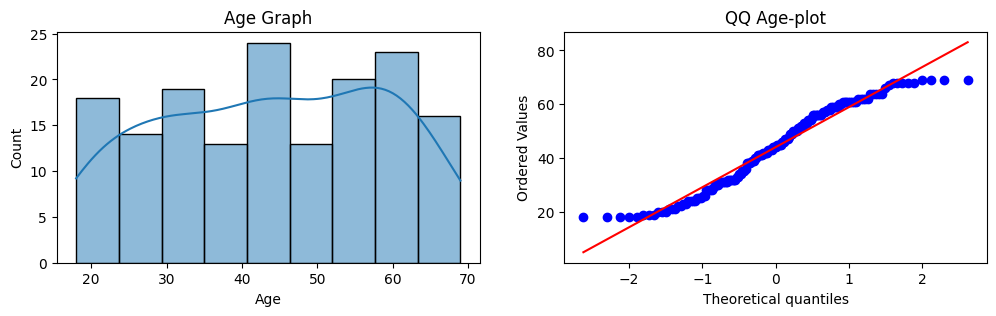

In [138]:
plt.figure(figsize = (12,3))
plt.subplot(121)
sns.histplot(x_train['Age'],kde=True)
plt.title('Age Graph')


plt.subplot(122)
stats.probplot(x_train['Age'],dist ='norm', plot = plt)
plt.title('QQ Age-plot')
plt.show()

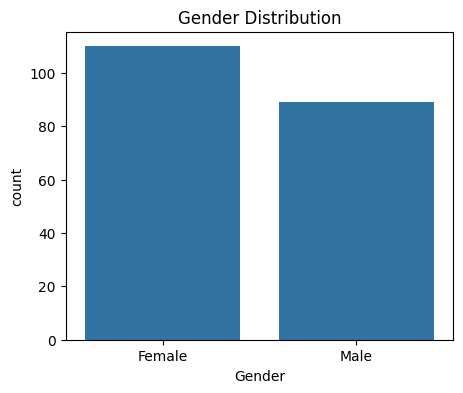

In [134]:
plt.figure(figsize = (5,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

Age                0.0
Gender             0.5
Speed_of_Impact    1.5
Helmet_Used        0.0
Seatbelt_Used      0.0
Survived           0.0
dtype: float64

In [91]:
df['Speed_of_Impact'].fillna(df['Speed_of_Impact'].mean() ,inplace = True)
df['Gender'].fillna(df['Gender'].mode()[0],inplace = True)

In [92]:
df.isnull().mean()*100

Age                0.0
Gender             0.0
Speed_of_Impact    0.0
Helmet_Used        0.0
Seatbelt_Used      0.0
Survived           0.0
dtype: float64

In [93]:
df['Helmet_Used'] = df['Helmet_Used'].map({'Yes':1, 'No':0})
df['Seatbelt_Used'] = df['Seatbelt_Used'].map({'Yes':1, 'No':0})
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [94]:
df.sample(2)

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
114,52,0,115.0,0,0,0
127,50,1,38.0,0,1,1


In [95]:
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns = ['Survived']),df['Survived'],test_size = 0.2,random_state = 42)

In [96]:
logreg = LogisticRegression()
logreg.fit(x_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [97]:
y_pred = logreg.predict(x_test)

In [100]:
print("Accuracy score is :--",accuracy_score(y_test , y_pred))
print("Confusion matrix is :--",confusion_matrix(y_test,y_pred))

Accuracy score is :-- 0.55
Confusion matrix is :-- [[15  7]
 [11  7]]


In [139]:
print("Classification Report is :--",classification_report(y_test,y_pred))

Classification Report is :--               precision    recall  f1-score   support

           0       0.59      0.73      0.65        22
           1       0.54      0.39      0.45        18

    accuracy                           0.57        40
   macro avg       0.57      0.56      0.55        40
weighted avg       0.57      0.57      0.56        40



In [3]:

#This is the code of chat-gpt that is given by


# import pandas as pd
# import warnings as wr
# wr.filterwarnings('ignore')
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# # Load dataset
# df = pd.read_csv(r"C:\Users\HP\Downloads\accident (1) .csv")

# df['Speed_of_Impact'].fillna(df['Speed_of_Impact'].mean() ,inplace = True)
# df['Gender'].fillna(df['Gender'].mode()[0],inplace = True)

# df['Helmet_Used'] = df['Helmet_Used'].map({'Yes':1, 'No':0})
# df['Seatbelt_Used'] = df['Seatbelt_Used'].map({'Yes':1, 'No':0})
# df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# # Target column (yaha apna target column naam daalo)
# X = df.drop("Survived", axis=1)
# y = df["Survived"]


# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Scaling
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # Model
# model = LogisticRegression(max_iter=1000, class_weight='balanced')
# model.fit(X_train, y_train)

# # Prediction
# y_pred = model.predict(X_test)

# # Evaluation
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
